# Résonateur de lecture

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
import scipy.constants as sc
path_fig="..//Figures/"
path_Sonnet="..//Sonnet/"

On cherche à simuler le résonateur de lectrue ci-dessus. La longueur totale du résonateur $\lambda/4$ est $L_{\mathrm{Res.}}= 4.841 \, \mathrm{mm}$ et la tension est sondé par le port 2 à travers une capacité de couplage $C_{\mathrm{c}}= 1 \, \mathrm{fF}$ (voir ci-dessous). 

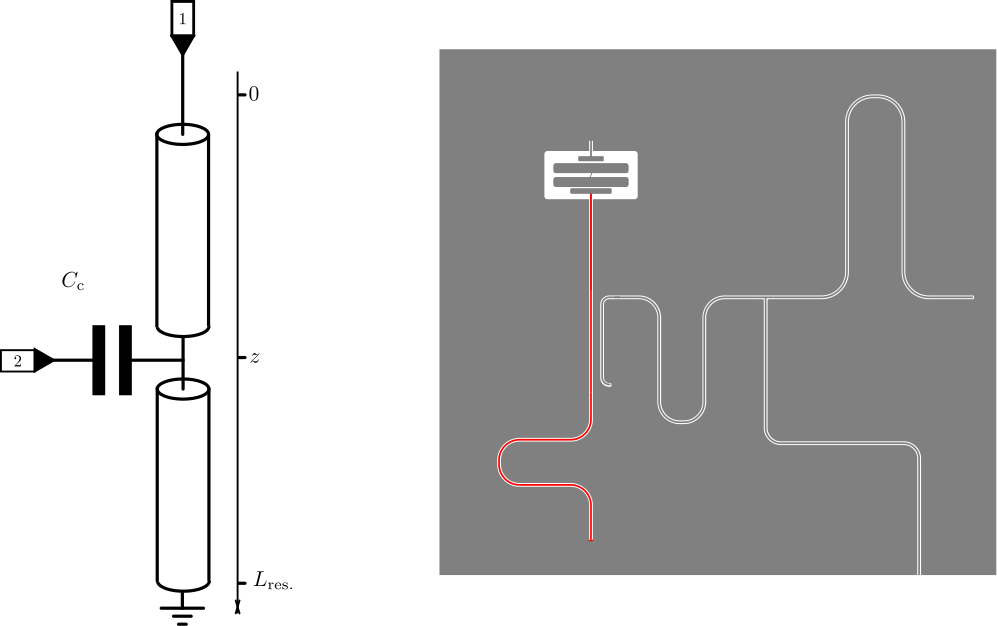

In [3]:
Image(filename=path_fig+"Resonator.png", width=600)

## Exercices

- Créer des lignes de transmission skrf définies par une longeur $z$ et $L_{\mathrm{Res.}}-z$, une impédance caractéristique $Z_0= 54.93 \Omega$ et une vitesse de propagation $v=1.26 \times 10^8 \, \mathrm{m.s}^{-1}$ en vous aidant de l'exemple ci-dessous:

        s_line = np.zeros((Nf, 2, 2), dtype=complex)

        s_line[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / c * L)

        s_line[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / c * L)

        CPW= rf.Network(frequency=freq, s=s_line, z0=50, name='CPW_a_b')

- Créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html) et un [élément de circuit discret simulant la capacité](https://scikit-rf.readthedocs.io/en/latest/examples/circuit/Lumped%20Element%20Circuits.html) $C_c$,
- Mesurer la fréquence de résonance $f_0$ sachant que $\mathrm{Im} Y(f_0)=0$, 
- Créer des [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) simulant le circuit ci-dessus pour différentes valeur de $\ell$.

In [28]:
Nz=20
L=4841e-6
l=L*np.linspace(0,1,Nz)
Cc=1e-15
Zc=54.93
v=1.26e8
Nf=10000
freq=rf.Frequency(4, 20, Nf, unit='ghz')

In [29]:
CPWa = []
CPWb = []

for i in range(0,Nz):
    s_line_a = np.zeros((Nf, 2, 2), dtype=complex)
    s_line_a[:, 0, 1] = np.exp(-1j * 2 * np.pi * freq.f / v * l[i])
    s_line_a[:, 1, 0] = np.exp(-1j * 2 * np.pi * freq.f  / v * l[i])
    cpwa= rf.Network(frequency=freq, s=s_line_a, z0=Zc, name='CPWa_'+str(i))
    CPWa.append(cpwa)
    s_line_b = np.zeros((Nf, 2, 2), dtype=complex)
    s_line_b[:, 0, 1] = np.exp(-1j * 2 * np.pi * freq.f  / v * (L-l[i]))
    s_line_b[:, 1, 0] = np.exp(-1j * 2 * np.pi * freq.f  / v * (L-l[i]))
    cpwb= rf.Network(frequency=freq, s=s_line_b, z0=Zc, name='CPWb_'+str(i))
    CPWb.append(cpwb)    

In [30]:
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
capa = rf.Circuit.SeriesImpedance(frequency=freq, name='capa', z0=Zc, Z=1/(1j*2*np.pi*freq.f*Cc))
Short = rf.circuit.Circuit.Ground(freq, name='GND')

In [31]:
connexion=[]
for k in range(len(l)):
    connexion.append([[(port1, 0), (CPWa[k], 0)],
                      [(CPWa[k],1),(capa,0), (CPWb[k],0)],
                      [(capa,1),(port2, 0)],
                      [(CPWb[k],1), (Short,0)],
                      ])


<Figure size 640x480 with 0 Axes>

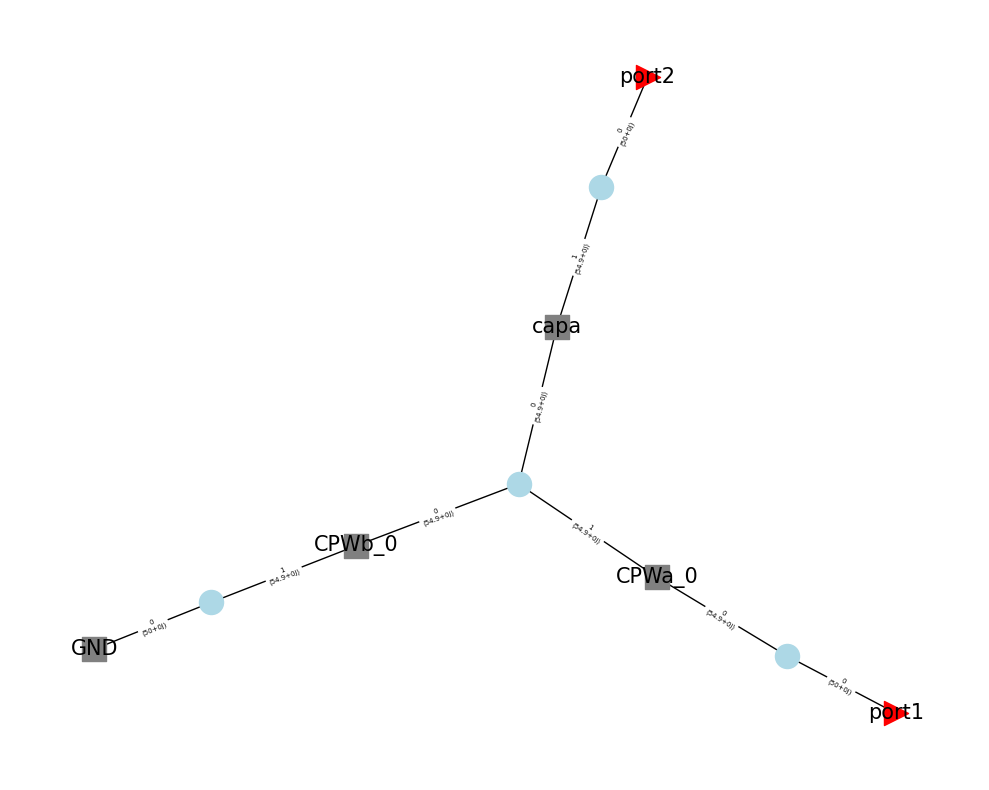

In [32]:
resulting_Circuit=[]
for k in range(len(l)):
    resulting_Circuit.append(rf.Circuit(connexion[k]))
plt.figure()
resulting_Circuit[0].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

In [33]:
for k in range(4):
    print(resulting_Circuit[0].port_indexes)


[0, 6]
[0, 6]
[0, 6]
[0, 6]


## Fréquence de résonance

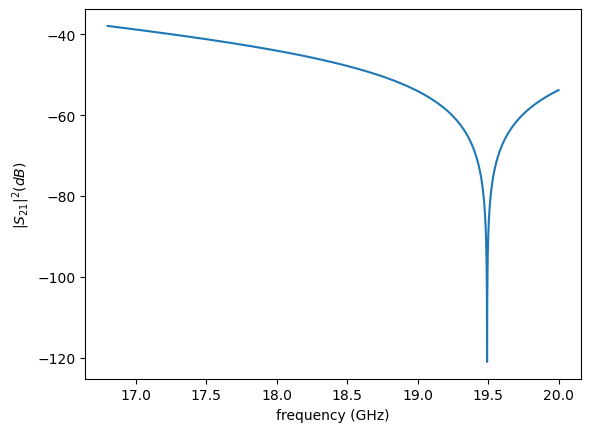

In [51]:
Y_Res=[]
plt.figure()
for k in range(len(l)):
    Gamma=resulting_Circuit[k].s[:,0,0]
    Y_Res.append(1/Zc*(1-Gamma)/(1+Gamma))
plt.plot(1e-9*(resulting_Circuit[0].frequency.f[8000:]),20*np.log10(Y_Res[0][8000:]))    
plt.xlabel("frequency (GHz)")
plt.ylabel("$|S_{21}|^2 (dB)$")
#plt.xlim(6.18,6.22)
plt.show()

In [39]:
Y_Res[0][1:3]

array([2.87711250e-08-0.01143101j, 2.87941395e-08-0.01142155j])

In [57]:
idx_min = np.argmin(20*np.log10(Y_Res[0][8000:]))
f0=resulting_Circuit[0].frequency.f[idx_min+8000]
print("f0 = "+ str(f0*1e-9) +" GHz")

f0 = 19.49274927492749 GHz


## Tension le long de la ligne de transmission

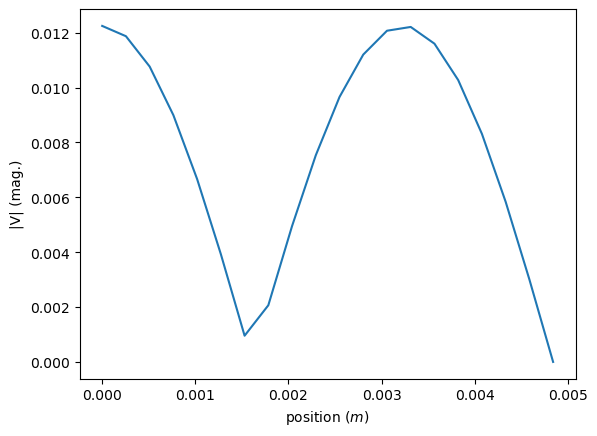

In [59]:
V= np.zeros(Nz, dtype=complex) 
for k in range(len(l)):
    V[k]=resulting_Circuit[k].s[idx_min+8000,0,6]
plt.figure()
plt.plot(l,np.abs(V))   
plt.xlabel("position ($m$)")
plt.ylabel("|V| (mag.)")
#plt.xlim(6.18,6.22)
plt.show()

### Fit du mode

In [25]:
# Define the  fitting function
def mode(x,A,lamb):
    y = A*np.cos(2*np.pi*x/lamb)
    return y

In [26]:
init = [0.04,0.01]  
Fit, covar =curve_fit(mode,l,np.abs(V), p0=init,bounds=([0,0], [1,1]))
print(Fit)

[0.00408263 0.01936163]


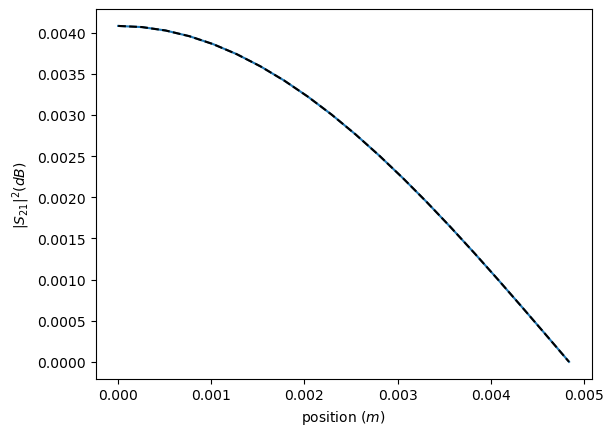

In [27]:
plt.figure()
plt.plot(l,np.abs(V))   
plt.plot(l, mode(l,Fit[0],Fit[1]),'--k') 
plt.xlabel("position ($m$)")
plt.ylabel("$|S_{21}|^2 (dB)$")
#plt.xlim(6.18,6.22)
plt.show()

In [88]:
print('fr = ' +str(v/(Fit[1])*1e-9) + ' GHz')

fr = 6.507718077219898 GHz
